In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
import warnings
import os
warnings.filterwarnings('ignore')

df = sns.load_dataset('diamonds')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
mlflow.set_tracking_uri(f"file:{os.path.abspath('./mlruns_diamonds')}")

X = df.drop('price', axis=1)
y = df['price']

# Категориальные признаки
cat_features = ['cut', 'color', 'clarity']
# Числовые признаки
num_features = ['carat', 'depth', 'table', 'x', 'y', 'z']

# Создаем пайплайн предобработки
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ])

# Применяем предобработку
X_processed = preprocessor.fit_transform(X)

# Разделяем на train/test
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

In [6]:
mlflow.set_tracking_uri("file:./mlruns_diamonds")

# Создаем эксперимент
mlflow.set_experiment("diamonds_price_prediction")

<Experiment: artifact_location='file:///home/stepan/Рабочий стол/mlops/lab3/mlruns_diamonds/406799550944105488', creation_time=1773490216341, experiment_id='406799550944105488', last_update_time=1773490216341, lifecycle_stage='active', name='diamonds_price_prediction', tags={}, workspace='default'>

In [7]:
def eval_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

In [8]:
# Список моделей для экспериментов
models = {
    "LinearRegression": {
        'model': LinearRegression(),
        'params': {}
    },
    "Ridge": {
        'model': Ridge(random_state=42),
        'params': {'alpha': [0.1, 1.0, 10.0, 100.0]}
    },
    "Lasso": {
        'model': Lasso(random_state=42, max_iter=10000),
        'params': {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}
    },
    "SGDRegressor": {
        'model': SGDRegressor(random_state=42, max_iter=1000, tol=1e-3),
        'params': {
            'alpha': [0.0001, 0.001, 0.01, 0.1],
            'penalty': ['l2', 'l1', 'elasticnet']
        }
    },
    "RandomForest": {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5]
        }
    },
    "GradientBoosting": {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [3, 5],
            'learning_rate': [0.05, 0.1]
        }
    }
}

results = []

# Для каждой модели запускаем эксперимент
for model_name, model_config in models.items():
    with mlflow.start_run(run_name=model_name):
        
        print(f"\n{'='*50}")
        print(f"Запуск эксперимента: {model_name}")
        print(f"{'='*50}")
        
        mlflow.log_param("model_type", model_name)
        mlflow.log_param("train_size", len(X_train))
        mlflow.log_param("test_size", len(X_test))

        if model_config['params']:
            print(f"Поиск по параметрам: {model_config['params']}")
            clf = GridSearchCV(model_config['model'], 
                               model_config['params'], 
                               cv=3, 
                               scoring='neg_mean_squared_error',
                               n_jobs=-1)
            clf.fit(X_train, y_train)
            
            best_model = clf.best_estimator_
            best_params = clf.best_params_
            
            for param_name, param_value in best_params.items():
                mlflow.log_param(f"best_{param_name}", param_value)
            
            print(f"Лучшие параметры: {best_params}")
        else:
            best_model = model_config['model']
            best_model.fit(X_train, y_train)
            best_params = {}

        y_pred_train = best_model.predict(X_train)
        y_pred_test = best_model.predict(X_test)

        rmse_train, mae_train, r2_train = eval_metrics(y_train, y_pred_train)
        rmse_test, mae_test, r2_test = eval_metrics(y_test, y_pred_test)

        mlflow.log_metric("rmse_train", rmse_train)
        mlflow.log_metric("mae_train", mae_train)
        mlflow.log_metric("r2_train", r2_train)
        mlflow.log_metric("rmse_test", rmse_test)
        mlflow.log_metric("mae_test", mae_test)
        mlflow.log_metric("r2_test", r2_test)

        results.append({
            'model': model_name,
            'best_params': best_params,
            'rmse_train': rmse_train,
            'rmse_test': rmse_test,
            'mae_test': mae_test,
            'r2_test': r2_test
        })

        signature = infer_signature(X_train, y_pred_train)
        mlflow.sklearn.log_model(best_model, f"model_{model_name}", signature=signature)
        
        print(f"\n Результаты для {model_name}:")
        print(f"   RMSE_train: {rmse_train:.2f}")
        print(f"   RMSE_test: {rmse_test:.2f}")
        print(f"   MAE_test: {mae_test:.2f}")
        print(f"   R2_test: {r2_test:.4f}")

# Создаем DataFrame с результатами
results_df = pd.DataFrame(results)
print("\n Сводная таблица результатов:")
print(results_df.sort_values('rmse_test'))

2026/03/19 17:55:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Запуск эксперимента: LinearRegression


2026/03/19 17:55:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



 Результаты для LinearRegression:
   RMSE_train: 1128.57
   RMSE_test: 1135.21
   MAE_test: 737.15
   R2_test: 0.9189

Запуск эксперимента: Ridge
Поиск по параметрам: {'alpha': [0.1, 1.0, 10.0, 100.0]}


2026/03/19 17:55:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/19 17:55:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

Лучшие параметры: {'alpha': 0.0001, 'penalty': 'l1'}

 Результаты для SGDRegressor:
   RMSE_train: 1129.37
   RMSE_test: 1136.27
   MAE_test: 736.41
   R2_test: 0.9188

Запуск эксперимента: RandomForest
Поиск по параметрам: {'n_estimators': [50, 100], 'max_depth': [5, 10, None], 'min_samples_split': [2, 5]}
Лучшие параметры: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


2026/03/19 17:57:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/19 17:57:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



 Результаты для RandomForest:
   RMSE_train: 257.07
   RMSE_test: 548.44
   MAE_test: 269.76
   R2_test: 0.9811

Запуск эксперимента: GradientBoosting
Поиск по параметрам: {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}


2026/03/19 17:57:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/19 17:57:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

 Результаты для GradientBoosting:
   RMSE_train: 530.37
   RMSE_test: 573.65
   MAE_test: 308.88
   R2_test: 0.9793

 Сводная таблица результатов:
              model                                        best_params  \
4      RandomForest  {'max_depth': None, 'min_samples_split': 5, 'n...   
5  GradientBoosting  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...   
2             Lasso                                     {'alpha': 0.1}   
1             Ridge                                     {'alpha': 1.0}   
0  LinearRegression                                                 {}   
3      SGDRegressor                 {'alpha': 0.0001, 'penalty': 'l1'}   

    rmse_train    rmse_test    mae_test   r2_test  
4   257.073656   548.439917  269.758111  0.981079  
5   530.367299   573.651265  308.882175  0.979299  
2  1128.571365  1135.168326  736.960086  0.918939  
1  1128.570286  1135.199383  737.140435  0.9189

In [9]:
results_display = results_df.copy()
results_display['rmse_test'] = results_display['rmse_test'].round(0)
results_display['mae_test'] = results_display['mae_test'].round(0)
results_display['r2_test'] = results_display['r2_test'].round(3)
print(results_display[['model', 'rmse_test', 'mae_test', 'r2_test']].sort_values('rmse_test'))

              model  rmse_test  mae_test  r2_test
4      RandomForest      548.0     270.0    0.981
5  GradientBoosting      574.0     309.0    0.979
0  LinearRegression     1135.0     737.0    0.919
1             Ridge     1135.0     737.0    0.919
2             Lasso     1135.0     737.0    0.919
3      SGDRegressor     1136.0     736.0    0.919


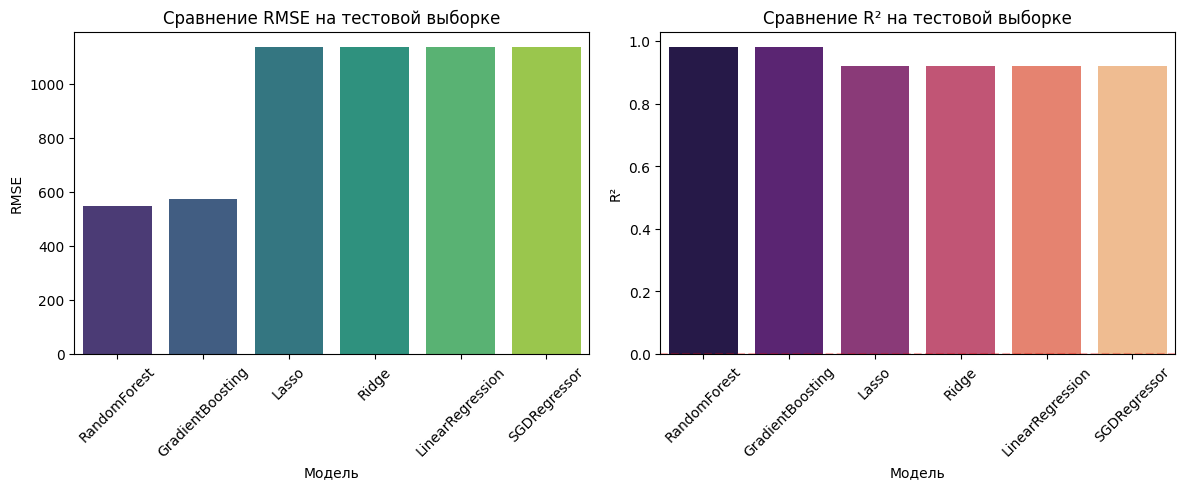

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(data=results_df.sort_values('rmse_test'), 
            x='model', y='rmse_test', palette='viridis')
plt.title('Сравнение RMSE на тестовой выборке')
plt.ylabel('RMSE')
plt.xlabel('Модель')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.barplot(data=results_df.sort_values('r2_test', ascending=False), 
            x='model', y='r2_test', palette='magma')
plt.title('Сравнение R² на тестовой выборке')
plt.ylabel('R²')
plt.xlabel('Модель')
plt.xticks(rotation=45)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
from mlflow.tracking import MlflowClient
import mlflow
import pandas as pd
import requests
import json

# Получаем лучшую модель
client = MlflowClient()
experiment = client.get_experiment_by_name("diamonds_price_prediction")

if experiment is None:
    print("Эксперимент не найден!")
else:
    # Получаем все запуски
    runs = client.search_runs(experiment_ids=[experiment.experiment_id])
    
    # Находим лучший по RMSE
    best_run = None
    best_rmse = float('inf')
    
    for run in runs:
        rmse = run.data.metrics.get('rmse_test')
        if rmse and rmse < best_rmse:
            best_rmse = rmse
            best_run = run
    
    if best_run:
        print(f"Лучшая модель:")
        print(f"  Run ID: {best_run.info.run_id}")
        print(f"  Run name: {best_run.info.run_name or 'unnamed'}")
        print(f"  RMSE: {best_rmse:.2f}")
        print(f"  R²: {run.data.metrics.get('r2_test', 0):.4f}")
        
        # Сохраняем run_id для дальнейшего использования
        BEST_RUN_ID = best_run.info.run_id
    else:
        print("Не найдено запусков с метриками")

Лучшая модель:
  Run ID: 19ea637e845e4c45985d22a732f8d798
  Run name: RandomForest
  RMSE: 548.44
  R²: 0.9189


In [ ]:
if best_run:
    # Определяем путь для сохранения
    import os
    model_local_path = "/home/stepan/Рабочий стол/mlops/lab3/best_diamonds_model"
    
    # Загружаем модель из MLflow
    MODEL_ARTIFACT_PATH = "model_RandomForest"
    MODEL_URI = f"runs:/{best_run.info.run_id}/{MODEL_ARTIFACT_PATH}"
    
    # Скачиваем и сохраняем локально
    local_path = mlflow.artifacts.download_artifacts(
        artifact_uri=MODEL_URI,
        dst_path=model_local_path
    )
    
    print(f"Модель сохранена локально: {local_path}")
    print(f"Содержимое папки: {os.listdir(local_path)}")

Модель сохранена локально: /home/stepan/Рабочий стол/mlops/lab3/best_diamonds_model/model_RandomForest/
Содержимое папки: ['requirements.txt', 'model.pkl', 'MLmodel', 'conda.yaml', 'python_env.yaml']


In [16]:
sample = X_test.mean(axis=0).tolist()

results = []
for i, feature in enumerate(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z'][:len(sample)]):
    for delta in [-0.3, -0.1, 0, 0.1, 0.3]:
        modified = sample.copy()
        modified[i] += delta
        req = {
            "dataframe_split": {
                "columns": [f"feature_{j}" for j in range(len(modified))],
                "data": [modified]
            }
        }
        resp = requests.post(url, json=req).json()
        price = resp['predictions'][0]
        results.append({
            'feature': feature,
            'delta': delta,
            'price': price
        })

df = pd.DataFrame(results)
print(df)


    feature  delta        price
0     carat   -0.3  3305.423234
1     carat   -0.1  3641.919171
2     carat    0.0  3704.050798
3     carat    0.1  3754.546798
4     carat    0.3  5243.017808
5       cut   -0.3  3707.289964
6       cut   -0.1  3704.907464
7       cut    0.0  3704.050798
8       cut    0.1  3700.682881
9       cut    0.3  3689.101714
10    color   -0.3  3716.918179
11    color   -0.1  3704.050798
12    color    0.0  3704.050798
13    color    0.1  3631.984619
14    color    0.3  3631.984619
15  clarity   -0.3  3697.015706
16  clarity   -0.1  3683.163873
17  clarity    0.0  3704.050798
18  clarity    0.1  3628.102595
19  clarity    0.3  3623.546143
20    depth   -0.3  2508.659988
21    depth   -0.1  3208.017202
22    depth    0.0  3704.050798
23    depth    0.1  3876.291810
24    depth    0.3  4014.169381
25    table   -0.3  3603.161655
26    table   -0.1  3615.777548
27    table    0.0  3704.050798
28    table    0.1  3672.441786
29    table    0.3  3749.821714
30      